In [1]:
pip install pandas pandas-datareader numpy statsmodels

In [2]:
import pandas as pd
import pandas_datareader.data as web
import numpy as np
import datetime

# 1. Define your timeframe (Galí 1999 starts around here)
start_date = datetime.datetime(1960, 1, 1)
end_date = datetime.datetime(2023, 12, 31)

# 2. Pull the data directly from FRED (No API key needed!)
tickers = ['OPHNFB', 'HOANBS', 'GDPDEF', 'FEDFUNDS', 'M2SL']
print("Fetching data from FRED...")
raw_data = web.DataReader(tickers, 'fred', start_date, end_date)

# 3. Fix the Frequencies (Convert Monthly to Quarterly)
# M2 and Fed Funds are monthly. This resamples everything to Quarterly ('QS') using the mean.
df_quarterly = raw_data.resample('QS').mean()

# 4. Perform the Math Transformations
final_df = pd.DataFrame()

# dlprod (Labor Productivity Growth): First difference of the natural log
final_df['dlprod'] = np.log(df_quarterly['OPHNFB']).diff() * 100

# hours (Log Hours): Natural log of hours worked
final_df['hours'] = np.log(df_quarterly['HOANBS'])

# inflation (Inflation Rate): First diff of natural log of GDP Deflator (annualized)
final_df['inflation'] = np.log(df_quarterly['GDPDEF']).diff() * 400

# fedfunds (Interest Rate): Keep as is (already a percentage rate)
final_df['fedfunds'] = df_quarterly['FEDFUNDS']

# dmoney (Money Growth): First difference of natural log of M2
final_df['dmoney'] = np.log(df_quarterly['M2SL']).diff() * 100

# Drop the first row (differencing always turns the first row into NaN)
final_df = final_df.dropna()

print("Data is ready for the SVAR!")
print(final_df.head())

Fetching data from FRED...
Data is ready for the SVAR!
              dlprod     hours  inflation  fedfunds    dmoney
DATE                                                         
1960-04-01 -1.571315  3.864155   1.009873  3.696667  0.822592
1960-07-01  0.594901  3.858559   1.368317  2.936667  1.766656
1960-10-01 -1.330749  3.849381   1.183814  2.296667  1.446953
1961-01-01  1.283413  3.843594   0.872746  2.003333  1.711260
1961-04-01  2.595363  3.841300   0.922013  1.733333  1.827441


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


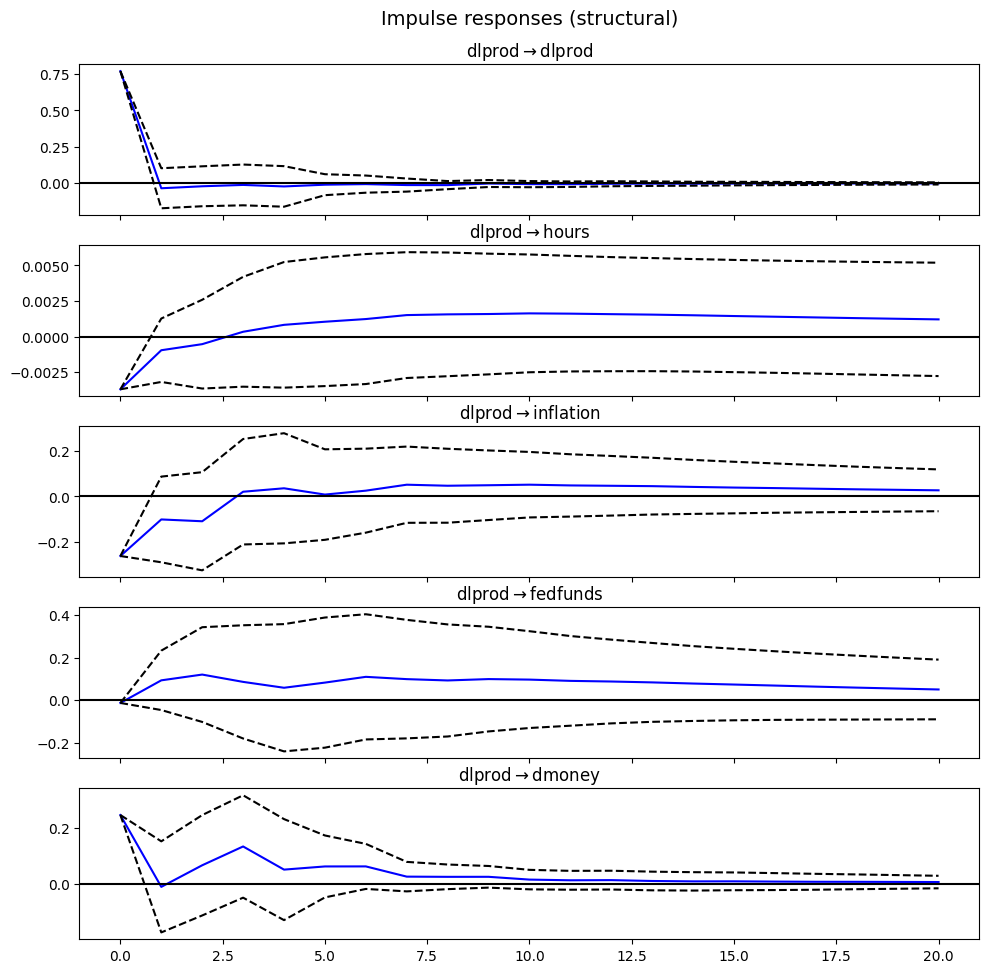

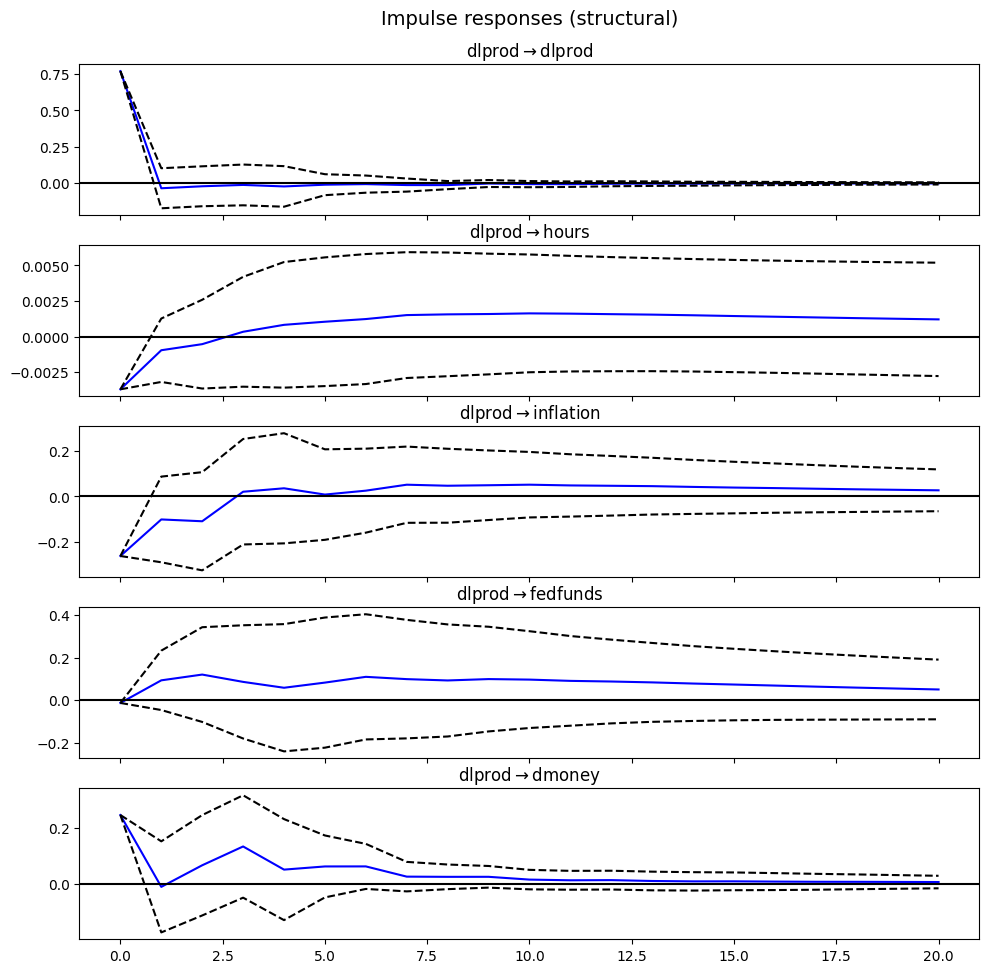

In [4]:
from statsmodels.tsa.api import SVAR
import numpy as np

# 1. Define your A matrix for the SVAR
# In statsmodels, 'E' means the parameter is Estimated, and 0 means it is strictly 0.
# This represents a lower-triangular Cholesky decomposition (like the CEE short-run model).
A_matrix = np.asarray([
    ['E',  0,   0,   0,   0 ],
    ['E', 'E',  0,   0,   0 ],
    ['E', 'E', 'E',  0,   0 ],
    ['E', 'E', 'E', 'E',  0 ],
    ['E', 'E', 'E', 'E', 'E']
])

# 2. Fit the SVAR model
# We set svar_type='A' and pass our A_matrix. We do not need a B matrix for this type.
model = SVAR(final_df, svar_type='A', A=A_matrix)

# 3. Fit the model with 4 lags
results = model.fit(maxlags=4)

# 4. Generate and plot the Structural IRFs
irf = results.irf(periods=20)

# Plot the shock to productivity (dlprod)
irf.plot(impulse='dlprod')

In [5]:
final_df.to_csv("clean_macro_data.csv")